# Riskfolio-Lib Tutorial: 
<br><a href="https://www.kqzyfj.com/click-101360347-15150084?url=https%3A%2F%2Flink.springer.com%2Fbook%2F9783031843037" target="_blank">
<div>
<img src="https://raw.githubusercontent.com/dcajasn/Riskfolio-Lib/refs/heads/master/docs/source/_static/Button.png" height="40" />
</div>
<br>
</a>
<a href="https://www.paypal.com/ncp/payment/GN55W4UQ7VAMN" target="_blank">
<div>
<img src="https://raw.githubusercontent.com/dcajasn/Riskfolio-Lib/refs/heads/master/docs/source/_static/Button2.png" height="40" />
</div>
</a>

<br><a href='https://ko-fi.com/B0B833SXD' target='_blank'><img height='36' style='border:0px;height:36px;' src='https://cdn.ko-fi.com/cdn/kofi1.png?v=2' border='0' alt='Buy Me a Coffee at ko-fi.com' /></a> 
<br>
<br>__[Financionerioncios](https://financioneroncios.wordpress.com)__
<br>__[Orenji](https://www.linkedin.com/company/orenj-i)__
<br>__[Riskfolio-Lib](https://portfoliooptimization.org)__
<br>__[Dany Cajas](https://www.linkedin.com/in/dany-cajas/)__
## Tutorial 55: Mean Even Semi Moment of Order 2p Optimization

## 1. Downloading the data:

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import warnings

warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.4%}'.format

# Date range
start = '2016-01-01'
end = '2019-12-30'

# Tickers of assets
assets = ['JCI', 'AMZN', 'CMCSA', 'CPB', 'MO', 'APA', 'MRSH', 'JPM',
          'ZION', 'AAPL', 'BAX', 'BMY', 'LUV', 'PCAR', 'TXT', 'TMO',
          'DE', 'MSFT', 'HPQ', 'SHW', 'VZ', 'CNP', 'NI', 'T', 'BA']
assets.sort()

# Downloading data
data = yf.download(assets, start = start, end = end, auto_adjust=False)
data = data.loc[:,('Adj Close', slice(None))]
data.columns = assets

[*********************100%***********************]  25 of 25 completed


In [2]:
# Calculating returns

Y = data[assets].iloc[-300:,:].pct_change().dropna()

display(Y.head())

,AAPL,AMZN,APA,BA,BAX,BMY,CMCSA,CNP,CPB,DE,...,MRSH,MSFT,NI,PCAR,SHW,T,TMO,TXT,VZ,ZION
Date,,,,,,,,,,,,,,,,,,,,,
2018-10-19,1.5230%,-0.3778%,0.0475%,-0.8599%,-1.4332%,-3.0011%,0.1113%,1.2968%,3.4361%,-0.8763%,...,0.5122%,0.1475%,0.6339%,-0.1823%,-0.8456%,1.1384%,-1.1144%,-1.2872%,0.4575%,-0.8026%
2018-10-22,0.6110%,1.4325%,-1.9240%,-0.0786%,-0.6335%,-6.2983%,-0.6392%,-1.1024%,0.0528%,-0.3221%,...,-0.1491%,0.8927%,-0.8661%,0.4483%,0.0942%,-0.6084%,-0.6075%,-0.8634%,0.1457%,-3.4490%
2018-10-23,0.9427%,-1.1513%,-3.6571%,-1.6658%,-0.4201%,-0.4520%,-0.2797%,-0.5034%,0.1844%,-3.9948%,...,-0.3112%,-1.3956%,0.4765%,-5.1240%,-0.4483%,1.0713%,-1.0808%,-1.8308%,4.0560%,4.0353%
2018-10-24,-3.4302%,-5.9083%,-4.5500%,1.3141%,-1.8041%,-3.5933%,-4.2918%,0.8674%,0.9995%,-4.1108%,...,-3.6334%,-5.3469%,3.5178%,-4.2683%,-3.4955%,-8.0557%,-1.2403%,-4.2187%,0.3671%,-3.3065%
2018-10-25,2.1898%,7.0887%,0.4741%,2.5716%,0.5186%,0.7782%,5.0411%,-0.5733%,-1.1718%,2.1585%,...,5.8824%,5.8444%,-1.0309%,0.4913%,-5.1302%,-1.2516%,4.3662%,1.3799%,-1.7241%,3.3538%


## 2. Estimating Mean - Even Semi Moment of order 2p Portfolios

The Even Semi Moment of order 2p portfolio model proposed by __[Cajas (2026)](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=6518258)__ shows how to optimize the even semi moments of portfolio returns using sample data. 

### 2.1 Calculating the portfolio that optimize return/ even semi moment of order 2p ratio.

In [3]:
import riskfolio as rp
import mosek

# Building the portfolio object
port = rp.Portfolio(returns=Y)

# Calculating optimum portfolio

# Select method and estimate input parameters:

method_mu='hist' # Method to estimate expected returns based on historical data.
method_cov='hist' # Method to estimate covariance matrix based on historical data.

port.assets_stats(method_mu=method_mu,
                  method_cov=method_cov,
                  )

# Estimate optimal portfolio:

port.solvers = ['MOSEK'] # It is recommended to use mosek when optimizing Semi Kurtosis
port.p_esm = 4 # p of the order 2 * p_esm of the Even Semi Moment

model ='Classic' # Could be Classic (historical), BL (Black Litterman) or FM (Factor Model)
rm = 'ESM' # Risk measure used, this time will be Even Semi Moment
obj = 'Sharpe' # Objective function, could be MinRisk, MaxRet, Utility or Sharpe
hist = True # Use historical scenarios for risk measures that depend on scenarios
rf = 0 # Risk free rate
l = 0 # Risk aversion factor, only useful when obj is 'Utility'

w = port.optimization(model=model, rm=rm, obj=obj, rf=rf, l=l, hist=hist)

display(w.T)

,AAPL,AMZN,APA,BA,BAX,BMY,CMCSA,CNP,CPB,DE,...,MRSH,MSFT,NI,PCAR,SHW,T,TMO,TXT,VZ,ZION
weights,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,...,28.4790%,0.0000%,0.0000%,0.0000%,35.1787%,0.0000%,5.9226%,0.0000%,24.6333%,0.0000%


### 2.2 Plotting portfolio composition

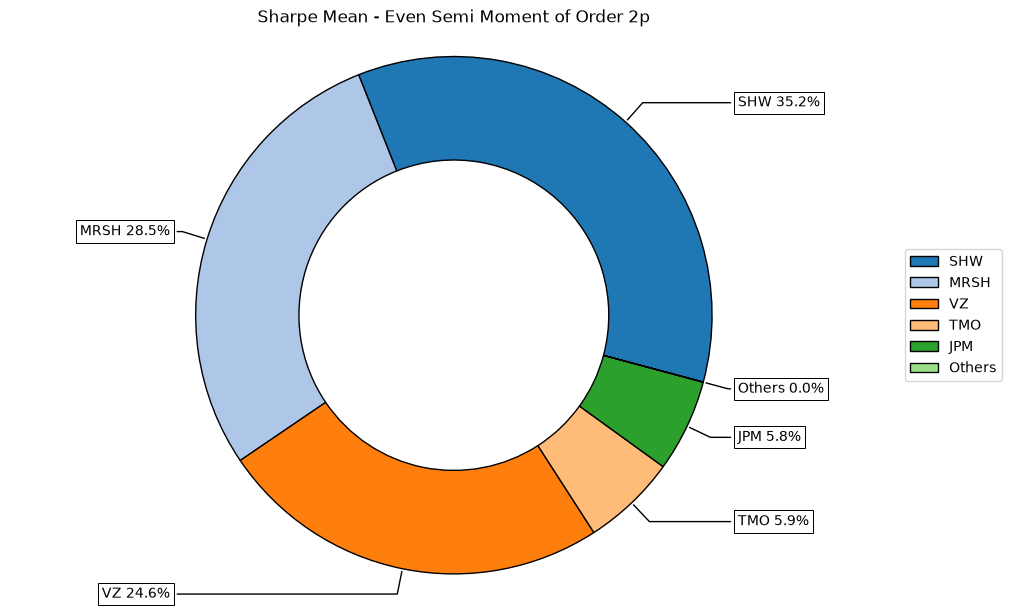

In [4]:
# Plotting the composition of the portfolio

ax = rp.plot_pie(w=w,
                 title='Sharpe Mean - Even Semi Moment of Order 2p',
                 others=0.05,
                 nrow=25,
                 cmap = "tab20",
                 height=6,
                 width=10,
                 ax=None)

### 2.3 Plotting risk measures

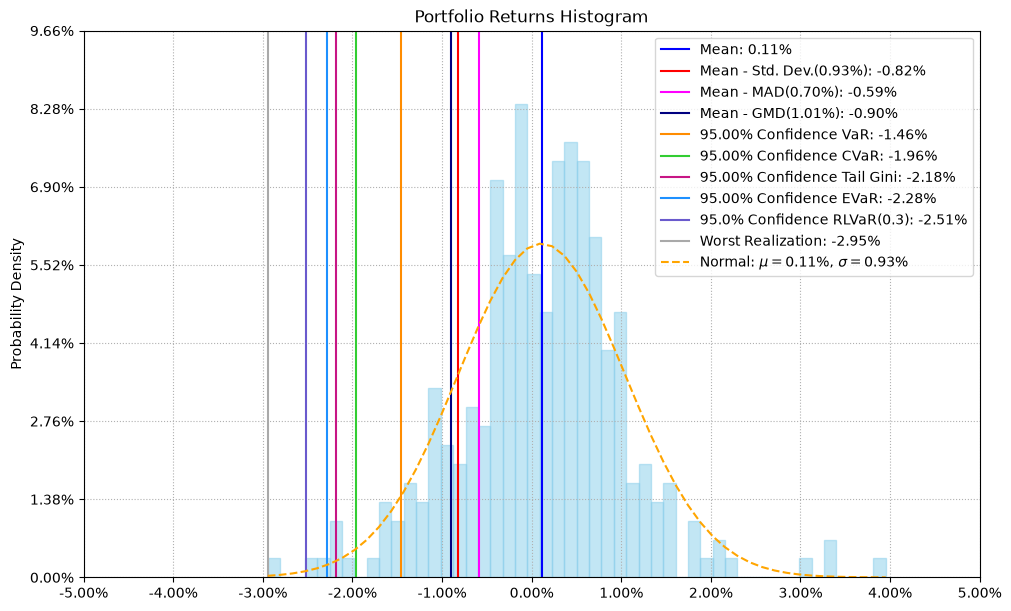

In [5]:
ax = rp.plot_hist(returns=Y,
                  w=w,
                  alpha=0.05,
                  bins=50,
                  height=6,
                  width=10,
                  ax=None)

### 2.4 Calculate efficient frontier

In [6]:
points = 50 # Number of points of the frontier

frontier = port.efficient_frontier(model=model, rm=rm, points=points, rf=rf, hist=hist)

display(frontier.T.head())

The problem doesn't have a solution with actual input parameters
The problem doesn't have a solution with actual input parameters
The problem doesn't have a solution with actual input parameters
The problem doesn't have a solution with actual input parameters
The problem doesn't have a solution with actual input parameters
The problem doesn't have a solution with actual input parameters


,AAPL,AMZN,APA,BA,BAX,BMY,CMCSA,CNP,CPB,DE,...,MRSH,MSFT,NI,PCAR,SHW,T,TMO,TXT,VZ,ZION
0,0.0000%,0.0000%,0.0000%,0.0000%,2.0716%,12.3243%,13.1769%,13.4419%,0.0000%,0.0000%,...,4.1362%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,26.7547%,9.9110%
1,0.0000%,0.0000%,0.0000%,0.0000%,0.0012%,8.7510%,8.6794%,0.1783%,0.0000%,0.0000%,...,23.3050%,0.0000%,0.0002%,0.0000%,12.3813%,0.0000%,0.0001%,0.0000%,29.3720%,2.3911%
2,0.0000%,0.0000%,0.0000%,0.0000%,0.0003%,6.0875%,6.7651%,0.0000%,0.0005%,0.0000%,...,24.8393%,0.0009%,0.0001%,0.0002%,20.9019%,0.0000%,0.0104%,0.0000%,28.3965%,0.0002%
3,0.0000%,0.0000%,0.0000%,0.0000%,0.0001%,4.3225%,3.6958%,0.0000%,0.0004%,0.0000%,...,25.9386%,0.0005%,0.0000%,0.0001%,25.8859%,0.0000%,0.1372%,0.0000%,28.7023%,0.0001%
4,0.0001%,0.0000%,0.0000%,0.0000%,0.0003%,2.9293%,0.9656%,0.0001%,0.0011%,0.0000%,...,26.5980%,0.0016%,0.0001%,0.0004%,29.5191%,0.0001%,0.6100%,0.0000%,29.2033%,0.0002%


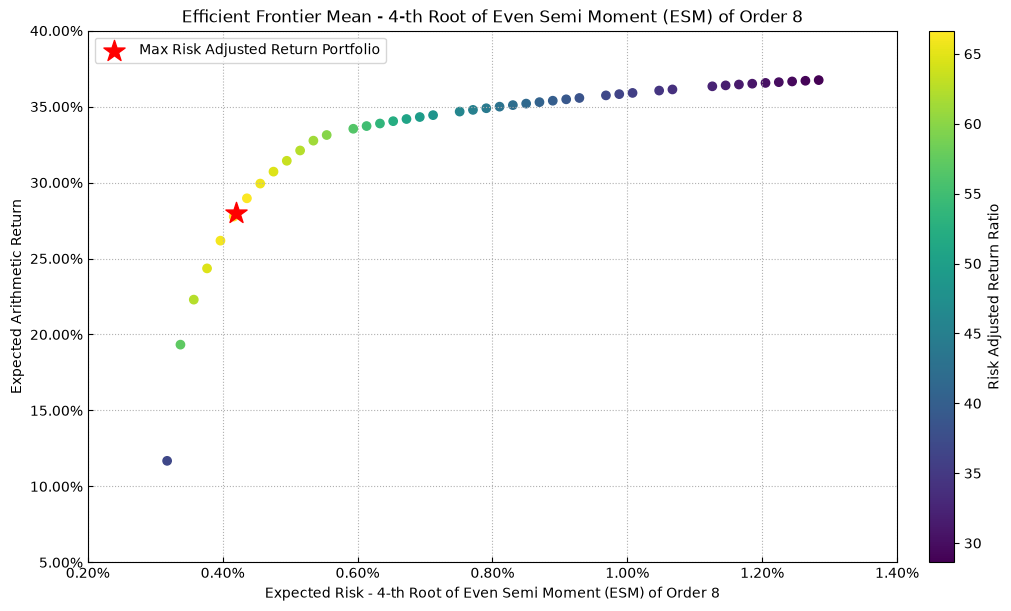

In [7]:
# Plotting the efficient frontier

label = 'Max Risk Adjusted Return Portfolio' # Title of point
mu = port.mu # Expected returns
cov = port.cov # Covariance matrix
returns = port.returns # Returns of the assets

ax = rp.plot_frontier(
    w_frontier=frontier,
    mu=mu,
    cov=cov,
    returns=returns,
    rm=rm,
    rf=rf,
    p_esm=port.p_esm,
    cmap='viridis',
    w=w,
    label=label,
    marker='*',
    s=16,
    c='r',
    height=6,
    width=10,
    ax=None)

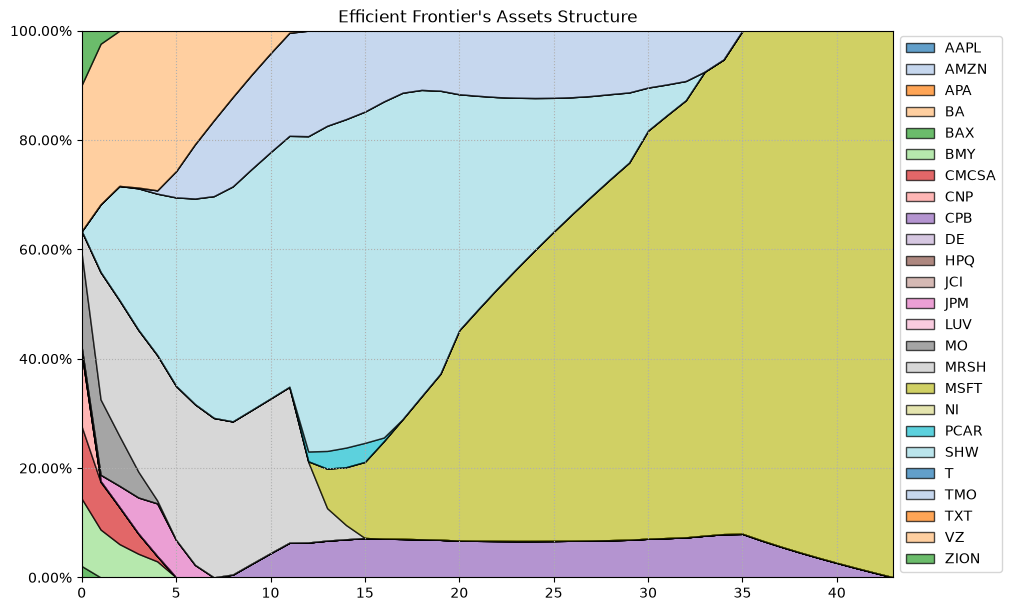

In [8]:
# Plotting efficient frontier composition

ax = rp.plot_frontier_area(w_frontier=frontier, cmap="tab20", height=6, width=10, ax=None)

## 3. Estimating Risk Parity Portfolios for Even Moment of Order 2p

### 3.1 Calculating the risk parity portfolio for Even Moment of Order 2p

In [9]:
b = None # Risk contribution constraints vector

w_rp = port.rp_optimization(model=model, rm=rm, rf=rf, b=b, hist=hist)

display(w_rp.T)

,AAPL,AMZN,APA,BA,BAX,BMY,CMCSA,CNP,CPB,DE,...,MRSH,MSFT,NI,PCAR,SHW,T,TMO,TXT,VZ,ZION
weights,2.7300%,3.0324%,2.6266%,3.6897%,4.2870%,4.6772%,4.1768%,5.3113%,3.7349%,2.4163%,...,3.9596%,2.9808%,4.8497%,3.4789%,3.9243%,3.8956%,3.7254%,3.7032%,7.5351%,3.7395%


### 3.2 Plotting portfolio composition

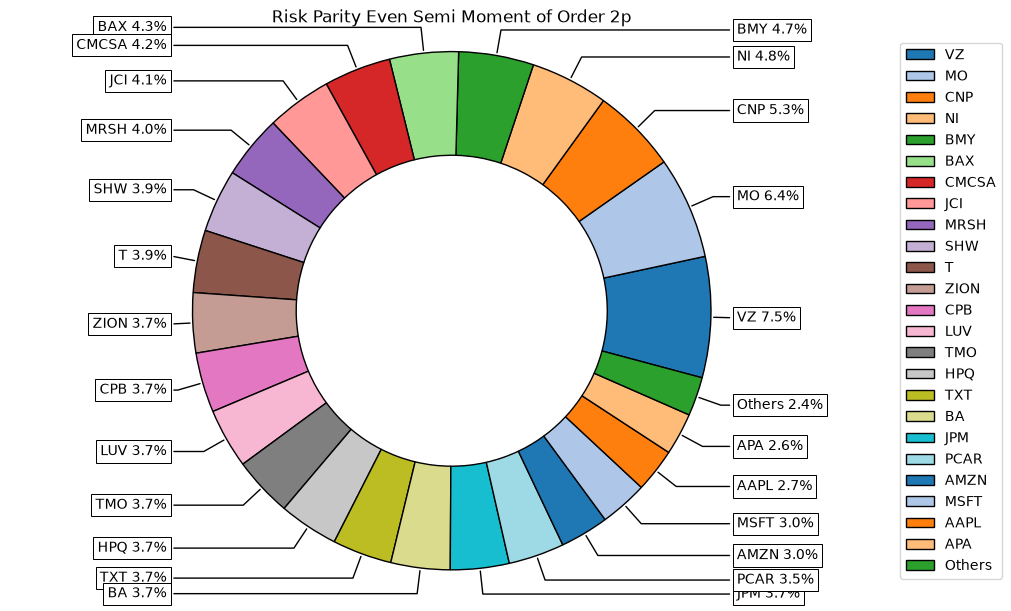

In [10]:
ax = rp.plot_pie(w=w_rp,
                 title='Risk Parity Even Semi Moment of Order 2p',
                 others=0.05,
                 nrow=25,
                 cmap="tab20",
                 height=6,
                 width=10,
                 ax=None)

### 3.3 Plotting Risk Composition

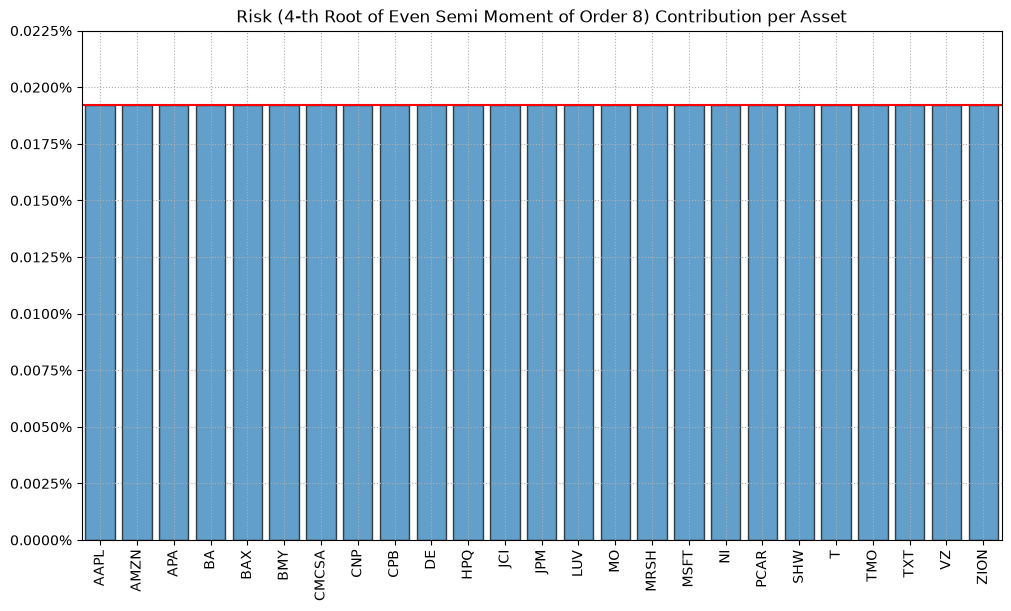

In [11]:
ax = rp.plot_risk_con(
    w=w_rp,
    cov=port.cov,
    returns=port.returns,
    rm=rm,
    rf=0,
    p_esm=port.p_esm,
    color="tab:blue",
    height=6,
    width=10,
    ax=None)

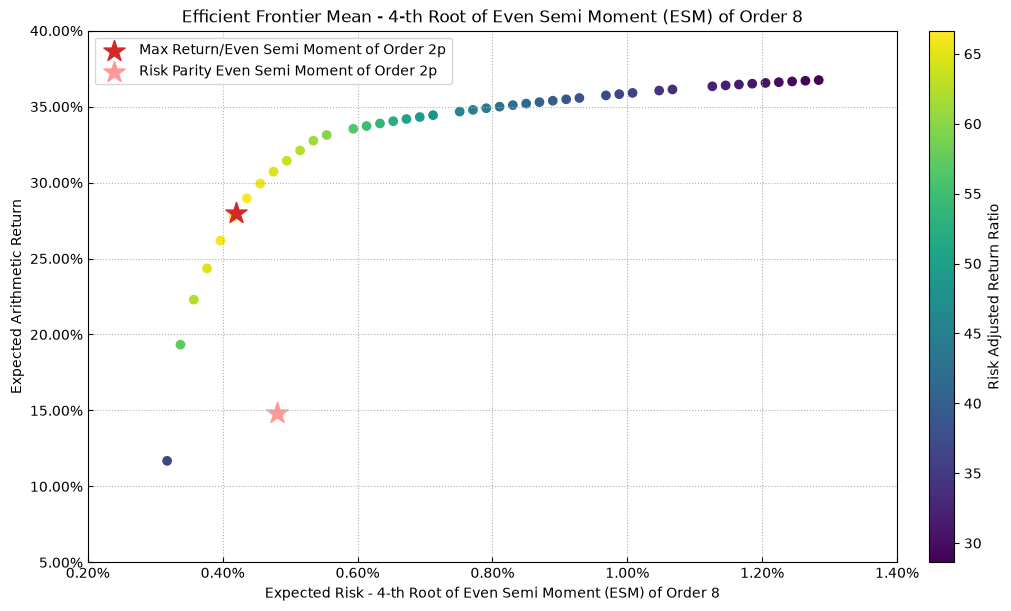

In [12]:
# Plotting the efficient frontier
ws = pd.concat([w, w_rp],axis=1)
ws.columns = ["Max Return/Even Semi Moment of Order 2p", "Risk Parity Even Semi Moment of Order 2p"]

mu = port.mu # Expected returns
cov = port.cov # Covariance matrix
returns = port.returns # Returns of the assets

ax = rp.plot_frontier(
    w_frontier=frontier,
    mu=mu,
    cov=cov,
    returns=returns,
    rm=rm,
    rf=rf,
    p_esm=port.p_esm,
    cmap='viridis',
    w=ws,
    label=label,
    marker='*',
    s=16,
    c='r',
    height=6,
    width=10,
    ax=None)
